# Comparaison Experts (Steam) vs Folksonomie (Joueurs)

## Objectif
S'appuyer sur **Lu et al. (2010)** pour comparer les métadonnées officielles de Steam (Genres et Catégories fournis par les développeurs) avec les tags utilisateurs.

Cette analyse permet de voir si les utilisateurs apportent une valeur ajoutée (granularité) ou s'ils se contentent de répéter les catégories officielles.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

db_path = '../data/2024-12-13.steam.db'
conn = sqlite3.connect(db_path)

# 1. Extraction des Genres Experts
query_genres = """
SELECT g.id, g.name, gr.label as expert_genre
FROM games g
JOIN game_genre gg ON g.id = gg.game_id
JOIN genres gr ON gg.genre_id = gr.id
"""
df_expert_genres = pd.read_sql_query(query_genres, conn)

# 2. Extraction des Catégories Experts (ex: Multi-player, Steam Achievements)
query_cats = """
SELECT g.id, c.label as expert_category
FROM games g
JOIN game_category gc ON g.id = gc.game_id
JOIN categories c ON gc.category_id = c.id
"""

try:
    df_expert_cats = pd.read_sql_query(query_cats, conn)
except:
    df_expert_cats = pd.DataFrame(columns=['id', 'label'])

conn.close()

# Chargement de notre base folksonomique structurée pour comparer
df_folk = pd.read_csv('../data/Games_Gameplay_Taxonomy.csv')

print(f"Données experts chargées. Nombre de jeux avec genres officiels : {df_expert_genres['id'].nunique()}")

Données experts chargées. Nombre de jeux avec genres officiels : 112332


*On a 112332 jeux avec un genre officiels.*

## 1. Analyse Quantitative : Richesse de l'information

Comparons le nombre moyen de labels par jeu entre experts et joueurs.

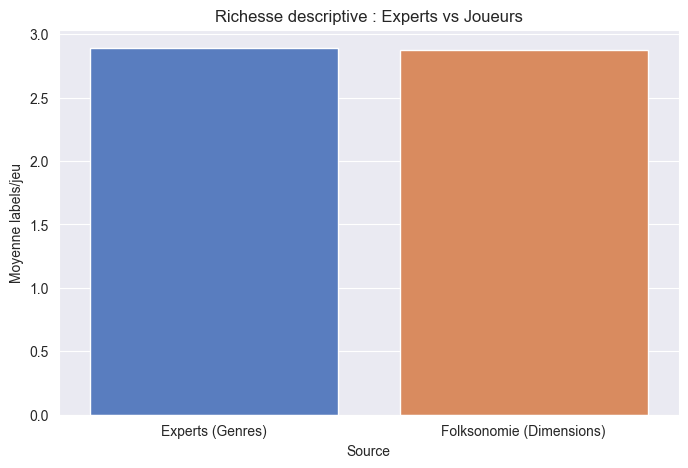

In [5]:
expert_counts = df_expert_genres.groupby('id').size()
folk_counts = df_folk.set_index('game_id')[['Genre', 'Mechanics', 'Theme', 'Mood']].notna().sum(axis=1)

stats = pd.DataFrame({
    'Source': ['Experts (Genres)', 'Folksonomie (Dimensions)'],
    'Moyenne labels/jeu': [expert_counts.mean(), folk_counts.mean()]
})

plt.figure(figsize=(8, 5))
# Correction du warning Seaborn : on assigne x à hue et on désactive la légende
sns.barplot(data=stats, x='Source', y='Moyenne labels/jeu', hue='Source', palette='muted', legend=False)
plt.title("Richesse descriptive : Experts vs Joueurs")
plt.show()

## 2. Analyse de l'Accord (Consensus)

Pour les jeux tagués 'RPG' par les experts, quel pourcentage est aussi tagué 'RPG' par les joueurs ?

In [3]:
# Préparation du croisement
common_ids = set(df_expert_genres['id']).intersection(set(df_folk['game_id']))

expert_rpg = set(df_expert_genres[df_expert_genres['expert_genre'] == 'RPG']['id'])
folk_rpg = set(df_folk[df_folk['Genre'].str.contains('RPG', na=False)]['game_id'])

agreement_rpg = len(expert_rpg.intersection(folk_rpg)) / len(expert_rpg) * 100
print(f"Accord sur le genre RPG : {agreement_rpg:.2f}% des jeux RPG officiels sont confirmés par les joueurs.")

Accord sur le genre RPG : 82.28% des jeux RPG officiels sont confirmés par les joueurs.


## 3. Le "Surplus Folksonomique" : Ce que les experts ne disent pas

Analysons les dimensions de notre taxonomie qui n'existent pratiquement pas dans les genres officiels (ex: Mécaniques, Mood).

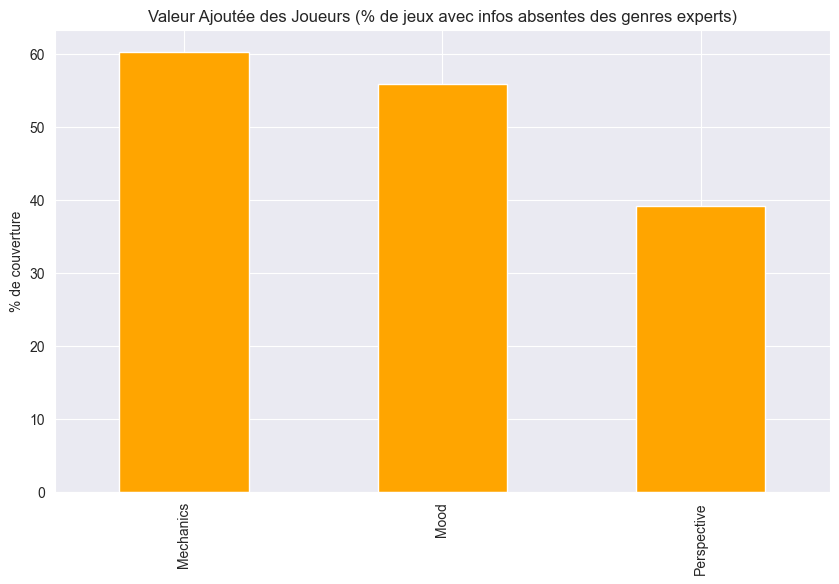

In [4]:
surplus = df_folk[['Mechanics', 'Mood', 'Perspective']].notna().mean() * 100

plt.figure(figsize=(10, 6))
surplus.plot(kind='bar', color='orange')
plt.title("Valeur Ajoutée des Joueurs (% de jeux avec infos absentes des genres experts)")
plt.ylabel("% de couverture")
plt.show()

## Conclusion de la comparaison

Conformément à la littérature :
1. **Validation** : Il y a un fort consensus sur les genres primaires (Action, RPG, Strategy).
2. **Granularité** : La folksonomie excelle là où les experts s'arrêtent. Les joueurs décrivent massivement les **Mécaniques** (Crafting, Permadeath) et l'**Ambiance** (Atmospheric, Dark), des données cruciales pour un système de recommandation ludologique.
3. **Complémentarité** : La base de données de gameplay structurée est donc un complément indispensable aux catégories marketing de Steam.
